In [1]:
import pandas as pd

In [2]:
# ファイルの読み込み
train_df = pd.read_csv("train.csv")

# 先頭5行の表示と情報の概要を取得
train_head = train_df.head()
train_info = train_df.info()
train_description = train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [3]:
# 確認する
print(train_head, train_info, train_description.T)

# 欠損値があるか確認
print(train_df.isnull().sum())

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

In [4]:
# labelに入ってる値の種類と、それぞれの件数を数える
train_df["label"].value_counts().sort_index()

,count
label,
0,4132
1,4684
2,4177
3,4351
4,4072
5,3795
6,4137
7,4401
8,4063


In [5]:
import matplotlib.pyplot as plt
import numpy as np

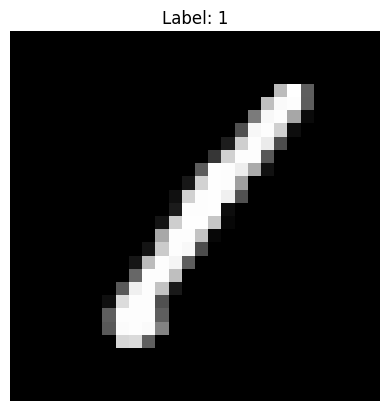

In [6]:
# 1番目の行を取り出して、画像のピクセルデータだけ抽出
image_data = train_df.iloc[0, 1:].values.reshape(28, 28)

# ラベル（正解の数字）を取得
label = train_df.iloc[0, 0]

# 画像を表示！
plt.imshow(image_data, cmap="gray")
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

# .iloc[0, 1:] : 0行目2列目以降を取り出してるよ！！
# .reshape(28 , 28) : 28×28に変形して画像にしている！！
# cmap ='gray' : グレースケール画像として表示

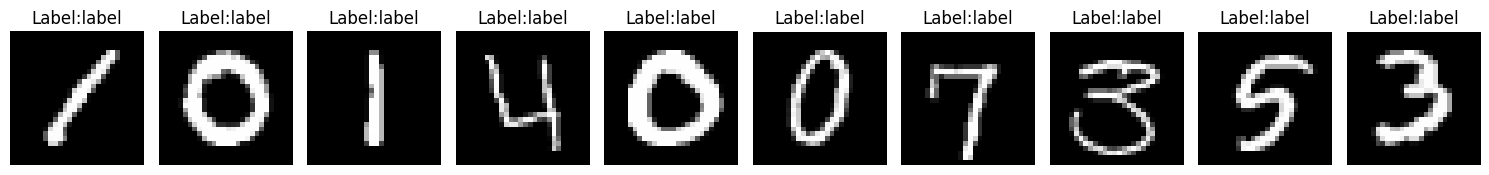

In [7]:
# 表示したい画像の枚数（今回は10枚）
num_images = 10

# グラフサイズを調整（横長に並べたい）
plt.figure(figsize=(15, 4))

# 0～9番目の画像を順番に表示
for i in range(num_images):
  image = train_df.iloc[i, 1:].values.reshape(28, 28)
  label = train_df.iloc[i, 0]

  #サブプロットで並べる
  plt.subplot(1, num_images, i + 1)
  plt.imshow(image, cmap='gray')
  plt.title(f"Label:{'label'}")
  plt.axis('off') #目盛り非表示

plt.tight_layout()
plt.show()

# plt.figure() : 全体の図サイズを設定！！
# plt.subplot(1, num_images, i + 1) : 1行10列で画像を並べる！！
# tight1_layout() : ラベルや画像が重ならないように調整してくれる！！

In [8]:
# 特徴量(pixelデータ)をX、ターゲット(label)をYに入れる
X = train_df.drop("label", axis=1)         #label列を除く
Y = train_df["label"]                            #正解ラベル

# スケーリング(255で割ることで0～1にする)
X = X / 255.0

# shapeを表示して確認
print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (42000, 784)
Y shape: (42000,)


In [9]:
from sklearn.model_selection import train_test_split

In [10]:
# 学習用と検証用に分割(80% : 20%)
X_train, X_valid, Y_train, Y_valid = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

# test_size=0.2 : 20%を検証用にする
# random_state=42 : 再現性を持たせる(実験ごとにバラバラにならないように)
# stratify=Y : 各ラベルのバランスを保って分割(分類問題では大事！！)

In [11]:
# 確認
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("Y_train shape:", Y_train.shape)
print("Y_valid.shape:", Y_valid.shape)


X_train shape: (33600, 784)
X_valid shape: (8400, 784)
Y_train shape: (33600,)
Y_valid.shape: (8400,)


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [13]:
# モデルを作成(100本の木で構成)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 学習！！
model.fit(X_train, Y_train)

# 予測！！
Y_pred = model.predict(X_valid)

# 精度！！
accuracy = accuracy_score(Y_valid, Y_pred)
print(f"検証データの正解率:{accuracy:.4f}")

検証データの正解率:0.9639


In [15]:
# test.csvを読み込む
test_df = pd.read_csv('test.csv')

# スケーリング(trainと同じ255で割る)
X_test = test_df / 255.0

# 予測する
Y_test_pred = model.predict(X_test)

# Sample_dataを読み込んで、予測データを代入
submission_df = pd.read_csv('sample_submission.csv')
submission_df["Label"] = Y_test_pred

# csvとして保存！！
submission_df.to_csv("submission.csv", index=False)
print("提出ファイルをsubmission.csv を作成しました")

提出ファイルをsubmission.csv を作成しました
